In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
COACH_DIR = Path("/Users/hyeon/SeSAC_Project/Coach")    # Coach의 절대경로 입력
RUN_FOLDER = "test12"
RUN_DIR = COACH_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)


In [2]:
knee = ps.joint_angle('left_knee', smooth=True, negative=True)

In [3]:
distance = ps.details["video"]['fps'] // 6

In [4]:
distance

10.0

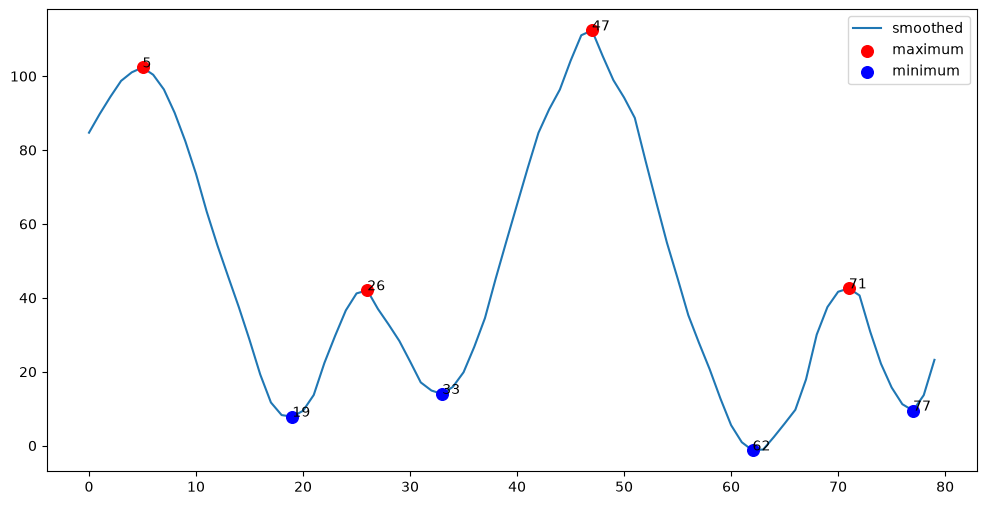

최댓값 프레임: [ 5 26 47 71]
최솟값 프레임: [19 33 62 77]


In [5]:
# 데이터 범위에 비례해 prominence 설정
signal_range = np.percentile(knee, 95) - np.percentile(knee, 5)
prominence = signal_range * 0.1    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

# 최댓값
max_indices, max_properties = find_peaks(
    knee,
    prominence=prominence,
    distance=distance,
)

# 최솟값: 신호에 -를 붙여서 봉우리로 변환
min_indices, min_properties = find_peaks(
    -knee,
    prominence=prominence,
    distance=distance,
)

plt.figure(figsize=(12, 6))
plt.plot(knee, label="smoothed")

plt.scatter(
    max_indices,
    knee[max_indices],
    color="red",
    s=70,
    label="maximum",
    zorder=3,
)

plt.scatter(
    min_indices,
    knee[min_indices],
    color="blue",
    s=70,
    label="minimum",
    zorder=3,
)

for i in max_indices:
    plt.annotate(str(i), (i, knee[i]))

for i in min_indices:
    plt.annotate(str(i), (i, knee[i]))

plt.legend()
plt.show()

print("최댓값 프레임:", max_indices)
print("최솟값 프레임:", min_indices)

In [6]:
start_index = (0 if knee[max_indices[0]] > knee[max_indices[1]] else 1)
for i in range(len(max_indices) // 2):
    assert knee[max_indices[2 * i + start_index]] > knee[max_indices[2 * i + 1 + start_index]]

In [7]:
start_frame = max_indices[start_index]

In [8]:
ps.cal_stride()

,frame,value,class
1,5,102.362463,1
2,19,7.840460,0
3,26,42.055110,1
4,33,13.985037,0
1,47,112.394342,1
2,62,-1.286926,0
3,71,42.568241,1
4,77,9.485681,0


In [9]:
ps.gct(
)

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0038972145631045066 / pixel 입니다.


[[21, 33], [68, 77]]

In [10]:
for i, j in [[1, 2], [3, 4]]:
    print(i, j)

1 2
3 4


In [11]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0038972145631045066 / pixel 입니다.


np.float64(438.7749179090156)

In [12]:
0.01 / ps.m_per_pixel

np.float64(2.5659351924503837)

In [13]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_video_frames(
    video_path,
    frames,
    hpe_start_frame=0,
    *,
    columns=2,
):
    """
    HPE 기준 프레임을 원본 영상 프레임으로 변환해 출력한다.

    Args:
        video_path:
            원본 영상 경로
        frames:
            HPE 기준 프레임 번호.
            정수, 리스트, 또는 ps.gct()의 [[td, to], ...] 형식
        hpe_start_frame:
            원본 영상에서 HPE 분석이 시작된 프레임 번호
        columns:
            이미지 출력 열 개수

    Returns:
        list[np.ndarray]:
            RGB 형식의 프레임 이미지
    """
    video_path = Path(video_path)

    if not video_path.is_file():
        raise FileNotFoundError(
            f"영상 파일이 없습니다: {video_path}"
        )

    try:
        hpe_frames = np.asarray(
            frames,
            dtype=float,
        ).reshape(-1)
    except (TypeError, ValueError) as exc:
        raise TypeError(
            "frames는 정수 또는 정수 배열이어야 합니다."
        ) from exc

    if hpe_frames.size == 0:
        raise ValueError("확인할 프레임이 없습니다.")

    if (
        not np.all(np.isfinite(hpe_frames))
        or not np.all(hpe_frames == np.floor(hpe_frames))
    ):
        raise ValueError("프레임 번호는 유한한 정수여야 합니다.")

    hpe_frames = hpe_frames.astype(int)

    # HPE 기준 프레임 → 원본 영상 프레임
    video_frames = hpe_frames + int(hpe_start_frame)

    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        raise RuntimeError(
            f"영상을 열지 못했습니다: {video_path}"
        )

    images = []

    try:
        frame_count = int(
            capture.get(cv2.CAP_PROP_FRAME_COUNT)
        )
        fps = float(
            capture.get(cv2.CAP_PROP_FPS)
        )

        invalid = video_frames[
            (video_frames < 0)
            | (video_frames >= frame_count)
        ]

        if invalid.size:
            raise IndexError(
                f"영상 프레임 범위를 벗어났습니다: "
                f"{invalid.tolist()} "
                f"(유효 범위: 0~{frame_count - 1})"
            )

        for video_frame in video_frames:
            capture.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(video_frame),
            )

            success, bgr_image = capture.read()

            if not success:
                raise RuntimeError(
                    f"{video_frame}번 프레임을 읽지 못했습니다."
                )

            rgb_image = cv2.cvtColor(
                bgr_image,
                cv2.COLOR_BGR2RGB,
            )
            images.append(rgb_image)

    finally:
        capture.release()

    columns = max(
        1,
        min(int(columns), len(images)),
    )
    rows = int(np.ceil(len(images) / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(5 * columns, 4 * rows),
    )
    axes = np.atleast_1d(axes).reshape(-1)

    for axis, image, hpe_frame, video_frame in zip(
        axes,
        images,
        hpe_frames,
        video_frames,
    ):
        seconds = (
            video_frame / fps
            if fps > 0
            else float("nan")
        )

        axis.imshow(image)
        axis.set_title(
            f"HPE {hpe_frame} → "
            f"video {video_frame} "
            f"({seconds:.3f}s)"
        )
        axis.axis("off")

    for axis in axes[len(images):]:
        axis.axis("off")

    figure.tight_layout()
    plt.show()

    return images

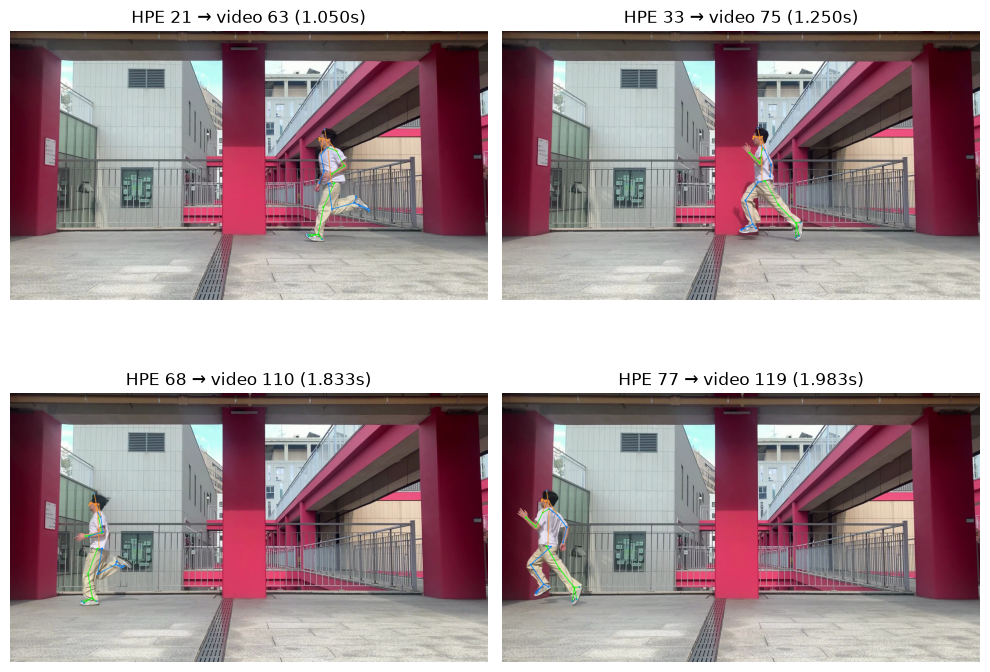

In [36]:
# pose_data에 기록된 실제 HPE 시작 프레임
hpe_start_frame = pose_data["frames"][0]["frame_num"]

# details.json의 relative_path는 Coach 폴더 기준
video_path = (
    Path("/Users/hyeon/SeSAC_Project/Coach")
    / 'run' / 'test12' / 'outputs' / 'output.mp4'
)

gct_frames = ps.gct()

images = show_video_frames(
    video_path,
    gct_frames,
    hpe_start_frame=hpe_start_frame,
)

In [15]:
ps.gct()

[[21, 33], [68, 77]]

In [16]:
np.resize([1, 2, 3, 4], sum(ps.strides.frame >= start_frame) + 4)[np.where(ps.strides.frame == start_frame)[0][0]:]

array([1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4])

In [17]:
max_indices

array([ 5, 26, 47, 71])

In [18]:
ps.cal_stride() 

이미 stride가 계산되어 있습니다.
Stride :    frame       value  class
1      5  102.362463      1
2     19    7.840460      0
3     26   42.055110      1
4     33   13.985037      0
1     47  112.394342      1
2     62   -1.286926      0
3     71   42.568241      1
4     77    9.485681      0


In [19]:
len(ps.strides)

8

In [20]:
ps.strides

,frame,value,class
1,5,102.362463,1
2,19,7.840460,0
3,26,42.055110,1
4,33,13.985037,0
1,47,112.394342,1
2,62,-1.286926,0
3,71,42.568241,1
4,77,9.485681,0


In [21]:
len(ps.gct())

2

In [22]:
a = 1

In [23]:
np.asarray(a).reshape(-1)[0]

np.int64(1)

In [24]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1613.719116,691.150635,1764.669800,236.764893,1652.956012,638.493954,1659.612053,648.108235,1651.476892,647.368675,...,1619.675806,255.401808,1878.521851,329.357821,1623.373607,256.880928,1851.897686,387.043510,1678.840616,253.922688
1,1605.129028,685.922974,1744.941650,237.139343,1633.400198,634.645912,1641.435061,642.680775,1631.939313,643.411217,...,1619.521797,249.702911,1851.071959,327.129777,1621.713123,252.624680,1822.584715,384.834705,1675.765843,254.816006
2,1584.568481,685.616272,1729.399292,240.101379,1614.201693,631.812227,1621.452913,639.788568,1612.751449,640.513690,...,1618.552425,247.497623,1820.136319,324.360544,1621.452913,250.398110,1791.131442,378.019564,1675.111935,254.748842
3,1583.039917,679.979248,1715.402466,230.097107,1594.303939,629.308955,1601.626240,637.363485,1593.571709,638.095715,...,1618.467530,246.352650,1786.148207,315.914503,1622.860910,247.817110,1763.449076,370.099525,1677.045932,251.478260
4,1556.182373,676.406860,1694.395874,231.687744,1573.897365,629.213370,1581.859459,637.175464,1573.897365,637.899291,...,1616.603142,245.585205,1749.787259,309.281957,1621.669929,247.756685,1735.310725,361.397481,1674.509280,251.375819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,93.631630,682.807953,343.917206,234.627686,192.513851,641.082855,196.161152,648.377455,194.702231,649.106915,...,212.209273,282.188495,297.556103,236.232510,215.127114,288.753636,332.570187,270.517134,243.576057,317.932039
76,75.319267,686.560547,336.419861,246.708801,175.085672,644.894877,178.665195,652.053923,177.949290,653.485732,...,181.528813,279.783555,294.641733,239.692900,185.824240,284.794887,322.562010,286.226696,215.176327,314.862878
77,58.728058,688.120850,325.735962,246.589539,157.018738,646.296132,159.893291,653.482514,159.893291,654.919790,...,135.459591,276.197468,298.590465,253.201046,135.459591,281.227936,308.651400,301.349805,184.326990,302.787081
78,37.983742,690.901581,308.907715,248.724792,139.620349,649.015686,141.779416,656.212574,142.499104,658.371640,...,94.999641,274.777503,292.194383,266.141237,94.279952,279.815325,298.671583,318.678521,148.256615,292.769723


In [25]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0038972145631045066 / pixel 입니다.


np.float64(438.7749179090156)

In [26]:
a = np.array([1, 2 ,3])

In [27]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0038972145631045066 / pixel 입니다.


np.float64(438.7749179090156)

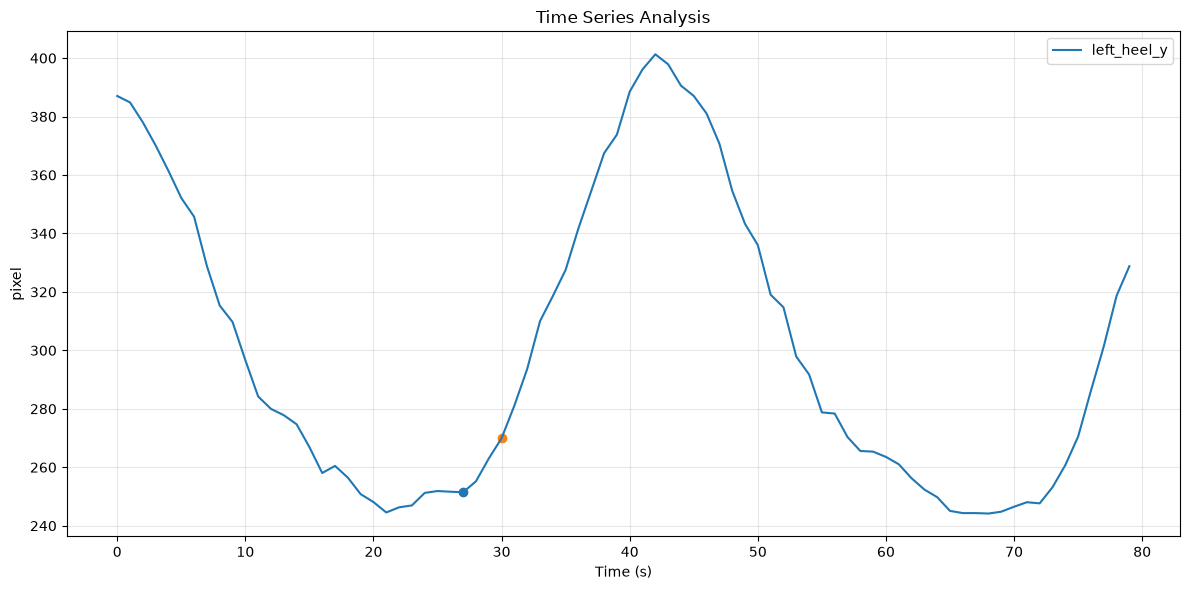

In [28]:
visualize_frame(ps.df[["left_heel_y"]], [27, 30])

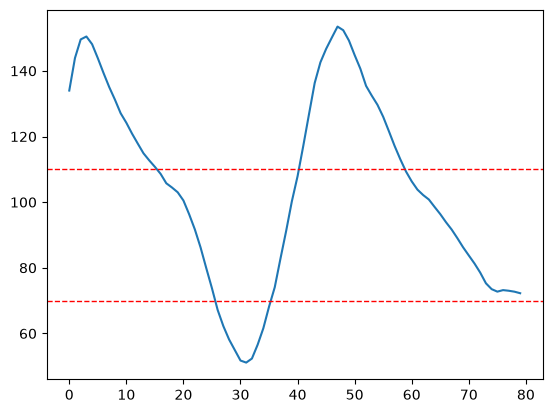

In [29]:
plt.plot(ps.joint_angle("left_elbow", smooth=True))
plt.axhline(y=70, color="red", linestyle="--", linewidth=1)
plt.axhline(y=110, color="red", linestyle="--", linewidth=1)

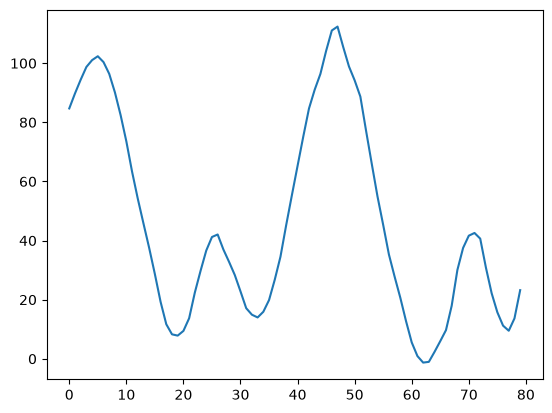

In [30]:
plt.plot(ps.joint_angle("left_knee", smooth=True, negative=True))

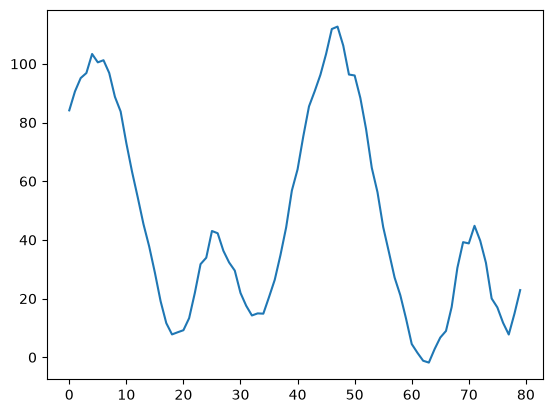

In [31]:
plt.plot(ps.joint_angle(("left_hip", "left_knee", "left_ankle"), negative=True))

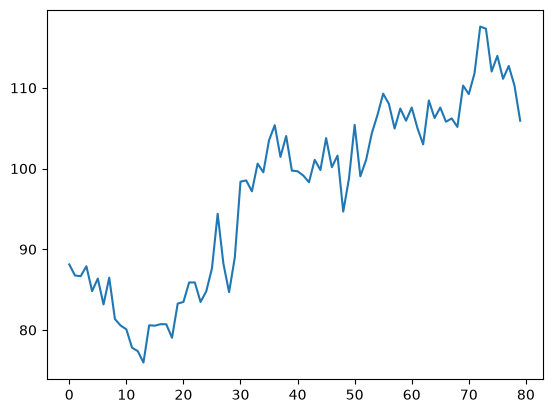

In [32]:
plt.plot(ps.joint_angle(("nose", "left_ear", "neck")))

In [33]:
ps.cal_stride()
ps.pixel2m()

이미 stride가 계산되어 있습니다.
Stride :    frame       value  class
1      5  102.362463      1
2     19    7.840460      0
3     26   42.055110      1
4     33   13.985037      0
1     47  112.394342      1
2     62   -1.286926      0
3     71   42.568241      1
4     77    9.485681      0
사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0038972145631045066 / pixel 입니다.


np.float64(438.7749179090156)

In [34]:
ps.cal_stride()

이미 stride가 계산되어 있습니다.
Stride :    frame       value  class
1      5  102.362463      1
2     19    7.840460      0
3     26   42.055110      1
4     33   13.985037      0
1     47  112.394342      1
2     62   -1.286926      0
3     71   42.568241      1
4     77    9.485681      0


In [35]:
n = 0
while True:
    assert 0, "1"


AssertionError: 1

In [ ]:
n

10